In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


100%|██████████| 170M/170M [00:06<00:00, 27.8MB/s]


In [3]:
def extract_edges(batch):
    edge_images = []

    for img in batch:
        img_np = img.permute(1, 2, 0).numpy()
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny((img_gray * 255).astype(np.uint8), 100, 200)
        edges = edges / 255.0
        edge_images.append(edges)

    edge_images = np.array(edge_images)
    edge_images = torch.tensor(edge_images).unsqueeze(1).float()
    return edge_images


In [4]:
def normalize(img):
    return img * 2 - 1


In [5]:
class EdgeToImageCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [6]:
model = EdgeToImageCNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)


In [7]:
epochs = 10

for epoch in range(epochs):
    for images, _ in loader:

        edge_imgs = extract_edges(images)

        images = normalize(images)
        edge_imgs = normalize(edge_imgs)

        optimizer.zero_grad()
        outputs = model(edge_imgs)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [1/10], Loss: 0.2540
Epoch [2/10], Loss: 0.2790
Epoch [3/10], Loss: 0.2191
Epoch [4/10], Loss: 0.2788
Epoch [5/10], Loss: 0.2628
Epoch [6/10], Loss: 0.1867
Epoch [7/10], Loss: 0.2902
Epoch [8/10], Loss: 0.2189
Epoch [9/10], Loss: 0.2114
Epoch [10/10], Loss: 0.2618


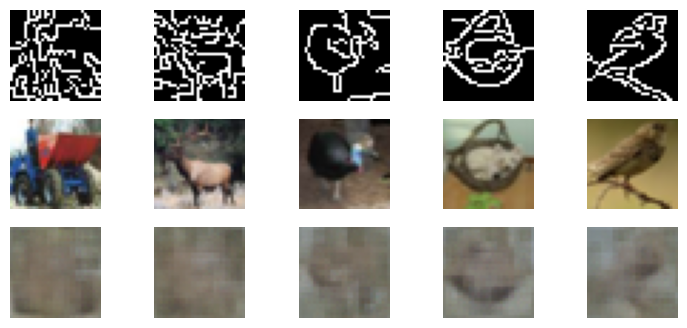

In [8]:
dataiter = iter(loader)
images, _ = next(dataiter)
edge_imgs = extract_edges(images)

images = normalize(images)
edge_imgs = normalize(edge_imgs)

with torch.no_grad():
    generated = model(edge_imgs)

# Denormalize
images = (images + 1) / 2
edge_imgs = (edge_imgs + 1) / 2
generated = (generated + 1) / 2

plt.figure(figsize=(9,4))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(edge_imgs[i][0], cmap='gray')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(generated[i].permute(1,2,0))
    plt.axis('off')

plt.show()
